# Heart Disease Classification — Deep Learning with PyTorch
### UCI Heart Disease Dataset | End-to-End Educational Guide

---

## What You Will Learn

| # | Topic |
|---|-------|
| 1 | Dataset loading, overview & EDA |
| 2 | Missing value handling & feature engineering |
| 3 | Data normalization & train/val/test splits |
| 4 | PyTorch `Dataset` & `DataLoader` |
| 5 | Building a Feedforward Neural Network (FNN) |
| 6 | Loss functions & optimizers |
| 7 | Training loop — forward pass, backpropagation, gradient descent |
| 8 | Regularization — Dropout & L2 weight decay |
| 9 | Batch Normalization |
| 10 | Learning rate scheduling |
| 11 | Evaluation — Accuracy, F1, ROC-AUC, Confusion Matrix |
| 12 | Comparing architectures (shallow vs deep) |
| 13 | Feature importance & model explainability |

---

> **Dataset**: [UCI Heart Disease](https://archive.ics.uci.edu/dataset/45/heart+disease) — 303 patients, 13 clinical features, binary classification (presence / absence of heart disease).

## Step 0 — Install & Import Dependencies

We use:
- `ucimlrepo` — load the dataset directly from UCI
- `pandas`, `numpy` — data manipulation
- `matplotlib`, `seaborn` — visualisation
- `scikit-learn` — preprocessing & classical metrics
- `torch` — deep learning framework
- `shap` — model explainability

In [1]:
# Install packages if not already available
import subprocess, sys
packages = ['ucimlrepo', 'torch', 'scikit-learn', 'matplotlib', 'seaborn', 'shap', 'pandas', 'numpy']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages ready!')

All packages ready!


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.10.0


---
## Step 1 — Load & Understand the Dataset

### What is this dataset?

The **Cleveland Heart Disease** database contains patient records from the Cleveland Clinic Foundation. The task is to predict whether a patient has heart disease (`num > 0`) or not (`num == 0`).

### The 13 Features

| Feature | Type | Description |
|---------|------|-------------|
| `age` | integer | Age in years |
| `sex` | binary | 1 = male, 0 = female |
| `cp` | categorical (1-4) | Chest pain type |
| `trestbps` | integer | Resting blood pressure (mm Hg) |
| `chol` | integer | Serum cholesterol (mg/dl) |
| `fbs` | binary | Fasting blood sugar > 120 mg/dl |
| `restecg` | categorical (0-2) | Resting ECG results |
| `thalach` | integer | Max heart rate achieved |
| `exang` | binary | Exercise-induced angina |
| `oldpeak` | float | ST depression (exercise vs rest) |
| `slope` | categorical (1-3) | Slope of peak exercise ST segment |
| `ca` | integer (0-3) | # major vessels coloured by fluoroscopy |
| `thal` | categorical | 3=normal, 6=fixed defect, 7=reversable defect |

**Target**: `num` — 0 = no disease, 1–4 = disease (we binarise to 0 vs 1)

In [3]:
# ── Load directly from UCI ML Repository ─────────────────────────
heart_disease = fetch_ucirepo(id=45)

X_raw = heart_disease.data.features.copy()
y_raw = heart_disease.data.targets.copy()

print('Feature matrix shape:', X_raw.shape)
print('Target shape        :', y_raw.shape)
print('\nFirst 5 rows of features:')
X_raw.head()

Feature matrix shape: (303, 13)
Target shape        : (303, 1)

First 5 rows of features:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [4]:
# Target distribution
print('Target value counts:')
print(y_raw['num'].value_counts().sort_index())

# Binarise: 0 = no disease, 1 = disease (values 1-4)
y_binary = (y_raw['num'] > 0).astype(int)
print('\nBinary target counts:')
print(y_binary.value_counts())

Target value counts:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Binary target counts:
num
0    164
1    139
Name: count, dtype: int64


In [5]:
# Basic stats
X_raw.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00


---
## Step 2 — Exploratory Data Analysis (EDA)

EDA helps us:
- Understand **distributions** of each feature
- Spot **outliers** and **missing values**
- See **correlations** between features
- Detect **class imbalance**

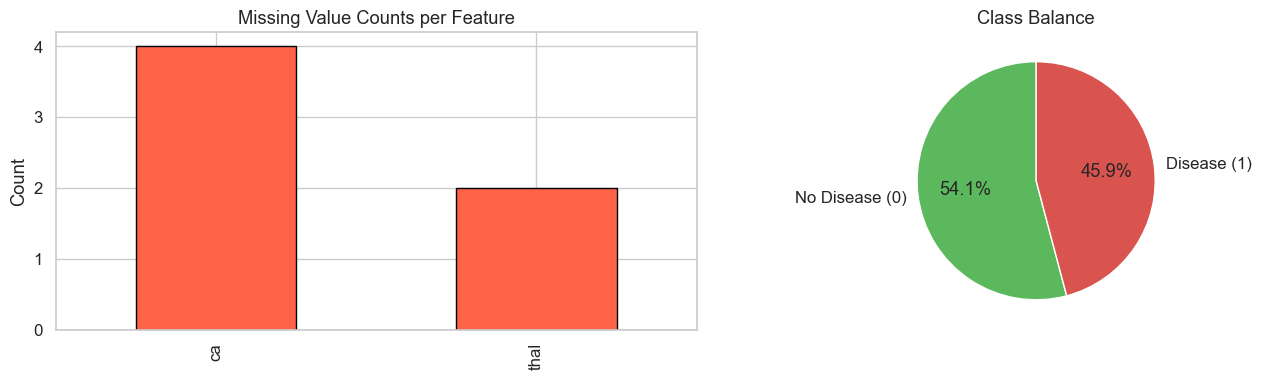

Missing values per column:
ca      4
thal    2
dtype: int64


In [6]:
# ── Missing Value Heatmap ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Counts
missing = X_raw.isnull().sum()
missing[missing > 0].plot(kind='bar', ax=axes[0], color='tomato', edgecolor='black')
axes[0].set_title('Missing Value Counts per Feature')
axes[0].set_ylabel('Count')

# Class balance
y_binary.value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                              labels=['No Disease (0)', 'Disease (1)'],
                              colors=['#5cb85c', '#d9534f'], startangle=90)
axes[1].set_title('Class Balance')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()
print('Missing values per column:')
print(missing[missing > 0])

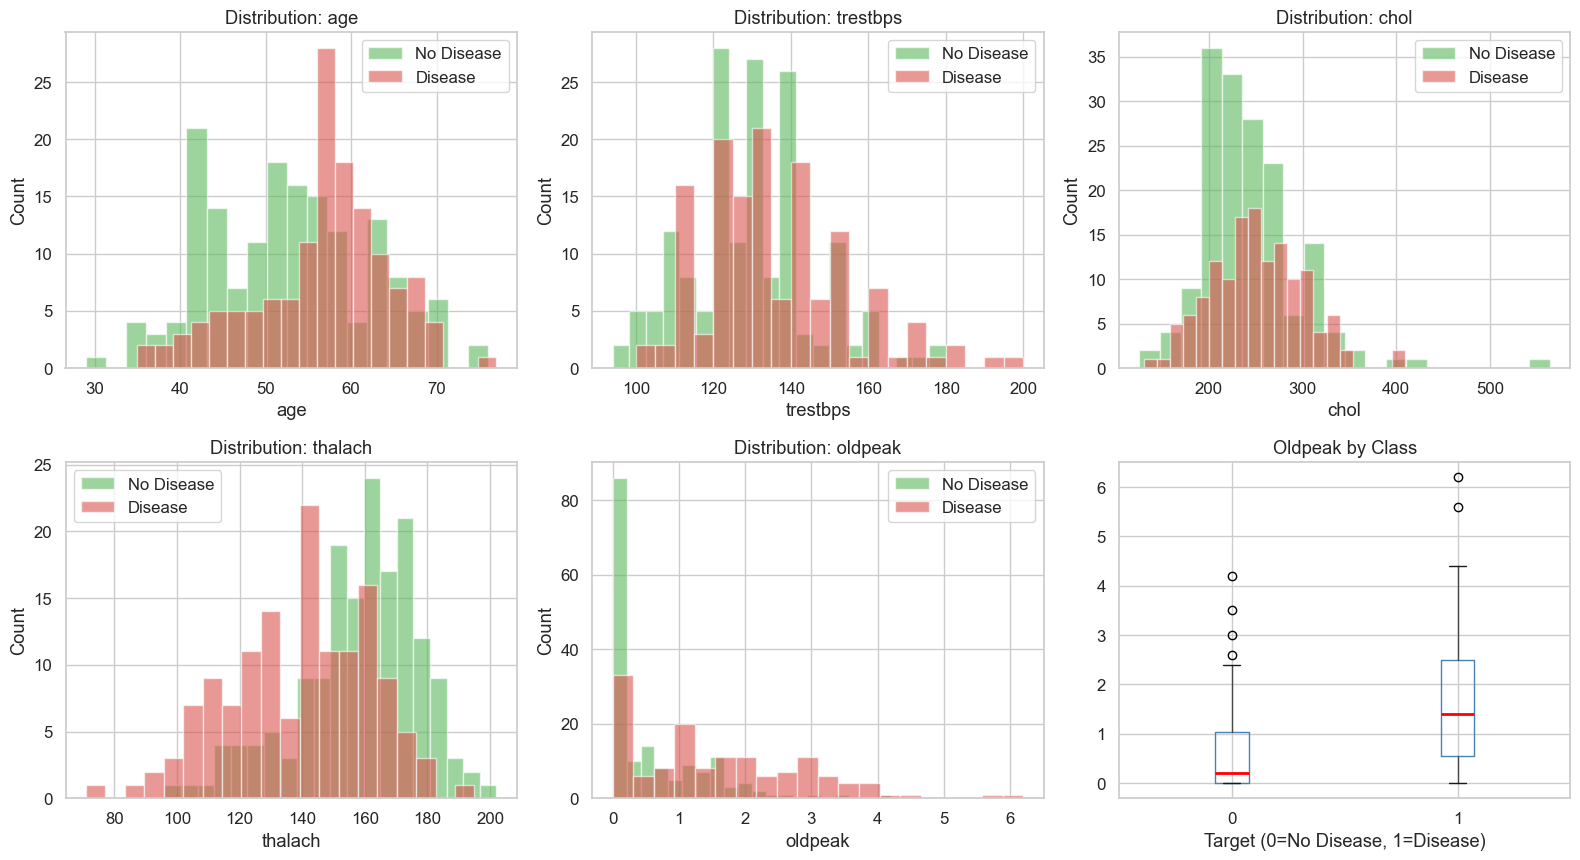

In [7]:
# ── Feature Distributions by Class ───────────────────────────────
df_eda = X_raw.copy()
df_eda['target'] = y_binary.values

numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    for cls, color, label in [(0, '#5cb85c', 'No Disease'), (1, '#d9534f', 'Disease')]:
        subset = df_eda[df_eda['target'] == cls][feat].dropna()
        axes[i].hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(f'Distribution: {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
    axes[i].legend()

# Boxplot for oldpeak
df_eda.boxplot(column='oldpeak', by='target', ax=axes[5],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
axes[5].set_title('Oldpeak by Class')
axes[5].set_xlabel('Target (0=No Disease, 1=Disease)')
plt.suptitle('')
plt.tight_layout()
plt.show()

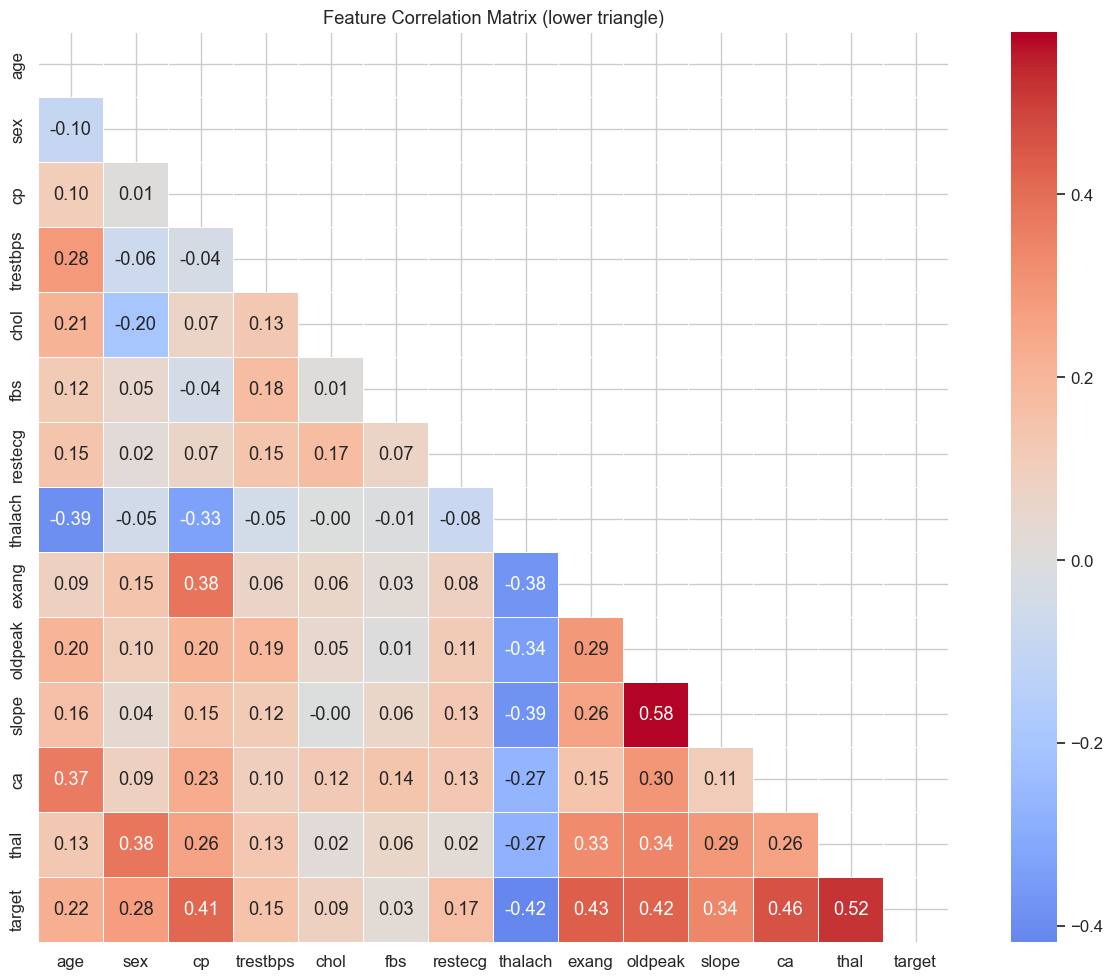

In [8]:
# ── Correlation Heatmap ───────────────────────────────────────────
# KEY INSIGHT: correlation shows linear relationships; neural nets capture
# non-linear ones too — this is just a starting point.
df_corr = df_eda.copy()
corr_matrix = df_corr.fillna(df_corr.median(numeric_only=True)).corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, center=0, linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix (lower triangle)')
plt.tight_layout()
plt.show()

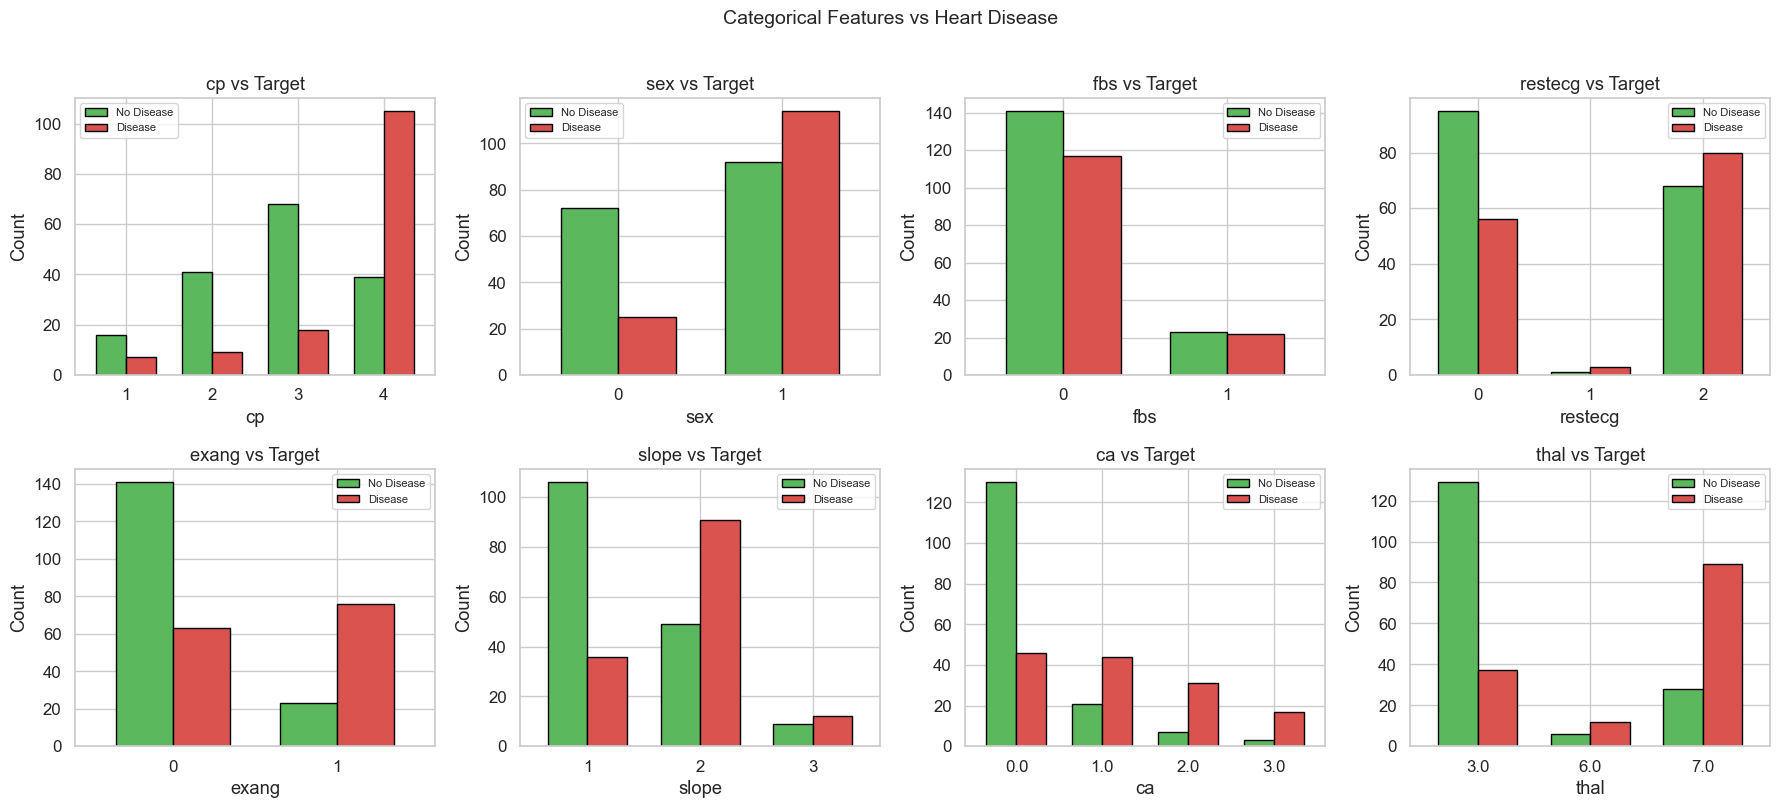

In [9]:
# ── Categorical Features vs Target ───────────────────────────────
cat_features = ['cp', 'sex', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    ct = pd.crosstab(df_eda[feat], df_eda['target'])
    ct.plot(kind='bar', ax=axes[i], color=['#5cb85c', '#d9534f'],
            edgecolor='black', width=0.7)
    axes[i].set_title(f'{feat} vs Target')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
    axes[i].legend(['No Disease', 'Disease'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Categorical Features vs Heart Disease', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Step 3 — Preprocessing

### 3a — Handle Missing Values

**Strategy**: Impute with the **median** for continuous features and **mode** for categorical ones.  
The median is robust to outliers (unlike the mean).

### 3b — Feature Scaling (StandardScaler)

Neural networks are sensitive to the **scale** of inputs. Without normalisation:
- Features with large ranges dominate gradient updates
- Training becomes slow and unstable

**StandardScaler** transforms each feature to have **mean = 0, std = 1**:
$$z = \frac{x - \mu}{\sigma}$$

> ⚠️ Always fit the scaler **only on train data**, then apply to val/test to avoid data leakage.

### 3c — Train / Validation / Test Split

| Set | Purpose | Size |
|-----|---------|------|
| Train | Learn model weights | 70% |
| Validation | Tune hyperparameters | 15% |
| Test | Final unbiased evaluation | 15% |

In [18]:
# ── 3a: Handle Missing Values ─────────────────────────────────────
# NOTE: pandas 2.x+ deprecated inplace= on column views.
#       Use explicit assignment: X[col] = X[col].fillna(...)
X = X_raw.copy()
y = y_binary.copy()

categorical_cols = ['cp', 'sex', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
continuous_cols  = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in continuous_cols:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

remaining = X.isnull().sum().sum()
print('Missing values after imputation:', remaining)
assert remaining == 0, "Still have NaN values — training will produce nan loss!"
print('Feature matrix shape:', X.shape)


Missing values after imputation: 0
Feature matrix shape: (303, 13)


In [19]:
# ── 3b & 3c: Split then Scale ─────────────────────────────────────
X_np = X.values.astype(np.float32)
y_np = y.values.astype(np.int64)

# 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_np, y_np, test_size=0.30, random_state=SEED, stratify=y_np
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

# Scale: FIT on train ONLY
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Sanity check — NaN in data = nan loss during training
for name, arr in [('X_train', X_train), ('X_val', X_val), ('X_test', X_test)]:
    n_nan = np.isnan(arr).sum()
    if n_nan > 0:
        raise ValueError(f"{name} still contains {n_nan} NaN values!")

print(f'Train : {X_train.shape[0]} samples')
print(f'Val   : {X_val.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')
print('No NaN values in any split ✓')


Train : 212 samples
Val   : 45 samples
Test  : 46 samples
No NaN values in any split ✓


---
## Step 4 — PyTorch `Dataset` and `DataLoader`

### Why do we need these?

**`Dataset`** — Wraps your data arrays into a PyTorch-compatible object. Defines how to get a *single sample*.

**`DataLoader`** — Wraps a `Dataset` and serves **mini-batches** during training. It handles:
- **Batching**: grouping samples into batches  
- **Shuffling**: randomising order each epoch  
- **Parallel loading**: optionally using multiple CPU workers

### What is a Mini-Batch?

Instead of computing gradients on one sample at a time (stochastic) or all samples at once (batch), we use **mini-batches** (e.g., 32 samples).  
This balances:
- **Computational efficiency** (GPU parallelism)
- **Gradient noise** (helps escape local minima)

In [20]:
# ── Convert to PyTorch tensors ────────────────────────────────────
def to_tensor_dataset(X, y):
    """Convert numpy arrays to a TensorDataset."""
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return TensorDataset(X_t, y_t)

train_ds = to_tensor_dataset(X_train, y_train)
val_ds   = to_tensor_dataset(X_val,   y_val)
test_ds  = to_tensor_dataset(X_test,  y_test)

BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# Inspect one batch
X_batch, y_batch = next(iter(train_loader))
print(f'Batch X shape : {X_batch.shape}  → (batch_size, n_features)')
print(f'Batch y shape : {y_batch.shape}  → (batch_size,)')
print(f'Data type     : {X_batch.dtype}')

Batch X shape : torch.Size([32, 13])  → (batch_size, n_features)
Batch y shape : torch.Size([32])  → (batch_size,)
Data type     : torch.float32


---
## Step 5 — Building a Feedforward Neural Network (FNN)

### Architecture Overview

```
Input (13 features)
    ↓
Linear(13 → 64)  →  BatchNorm1d  →  ReLU  →  Dropout(0.3)
    ↓
Linear(64 → 32)  →  BatchNorm1d  →  ReLU  →  Dropout(0.3)
    ↓
Linear(32 → 2)   →  [Logits for 2 classes]
```

### Key Components

**Linear (Fully Connected) Layer**:  
$$\mathbf{z} = \mathbf{W}\mathbf{x} + \mathbf{b}$$
Every input neuron is connected to every output neuron.

**ReLU Activation**:  
$$\text{ReLU}(z) = \max(0, z)$$  
Introduces *non-linearity* — without it, stacking linear layers is equivalent to a single linear layer.

**Batch Normalization**:  
Normalises each mini-batch to have ~zero mean and ~unit variance.  
$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$  
Benefits: faster training, acts as regularisation, less sensitive to initialization.

**Dropout**:  
Randomly zeros out neurons with probability `p` during training.  
Prevents co-adaptation of neurons → reduces overfitting.

**Output Layer**:  
2 logits (raw scores, one per class). `CrossEntropyLoss` applies softmax internally.

In [21]:
class HeartNet(nn.Module):
    """
    Feedforward Neural Network for binary heart disease classification.
    
    Architecture:
        Input  → [Linear → BN → ReLU → Dropout] × n_layers → Linear → Logits
    """
    def __init__(self, input_dim=13, hidden_dims=[64, 32], dropout_p=0.3,
                 use_batchnorm=True):
        super(HeartNet, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))    # Weight matrix
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h_dim))     # Batch Normalisation
            layers.append(nn.ReLU())                      # Non-linearity
            layers.append(nn.Dropout(p=dropout_p))        # Regularisation
            prev_dim = h_dim
        
        layers.append(nn.Linear(prev_dim, 2))  # Output: 2 logits
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        """Forward pass: maps input features to class logits."""
        return self.network(x)


# Instantiate the network
model = HeartNet(input_dim=13, hidden_dims=[64, 32], dropout_p=0.3).to(DEVICE)
print(model)
print(f'\nTotal trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

HeartNet(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=2, bias=True)
  )
)

Total trainable parameters: 3,234


---
## Step 6 — Loss Function & Optimizer

### Loss Function: `CrossEntropyLoss`

For multi-class classification, Cross-Entropy measures how well the predicted probability distribution matches the true label:

$$\mathcal{L} = -\sum_{c} y_c \log(\hat{p}_c) = -\log(\hat{p}_{\text{true class}})$$

In PyTorch, `nn.CrossEntropyLoss` = `LogSoftmax` + `NLLLoss` (efficient and numerically stable).

### Optimizer: `Adam`

**Adam** (Adaptive Moment Estimation) combines:
- **Momentum**: uses past gradients to smooth updates
- **RMSProp**: adapts learning rate per parameter

Update rule:
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

**L2 Regularisation** (`weight_decay`): adds $\lambda \|\mathbf{W}\|^2$ to the loss, penalising large weights and reducing overfitting.

In [22]:
# ── Loss & Optimizer ──────────────────────────────────────────────
LR           = 1e-3     # Learning rate
WEIGHT_DECAY = 1e-4     # L2 regularisation strength

criterion = nn.CrossEntropyLoss()                          # Loss function
optimizer = optim.Adam(model.parameters(),                 # Optimizer
                        lr=LR, weight_decay=WEIGHT_DECAY)

# Learning Rate Scheduler
# ReduceLROnPlateau: halve LR if val_loss doesn't improve for 10 epochs
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                               patience=10)

print(f'Loss      : {criterion}')
print(f'Optimizer : {optimizer.__class__.__name__}  (lr={LR}, weight_decay={WEIGHT_DECAY})')
print(f'Scheduler : ReduceLROnPlateau')


Loss      : CrossEntropyLoss()
Optimizer : Adam  (lr=0.001, weight_decay=0.0001)
Scheduler : ReduceLROnPlateau


---
## Step 7 — The Training Loop

Each **epoch** processes the entire training dataset once. Each epoch consists of many **mini-batch iterations**.

### One Training Step (per batch)

```
1. Forward Pass  →  compute predictions (logits)
2. Compute Loss  →  how wrong are we?
3. Zero Gradients →  clear previous gradients
4. Backward Pass →  compute ∂Loss/∂each_weight  (autograd)
5. Optimizer Step → update weights using gradients
```

### `model.train()` vs `model.eval()`

- **`model.train()`**: enables Dropout & uses batch statistics in BatchNorm
- **`model.eval()`**: disables Dropout & uses running statistics in BatchNorm
- **`torch.no_grad()`**: disables gradient computation (saves memory during inference)

In [23]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one full pass over the training data."""
    model.train()          # ← activates dropout + batch norm (train mode)
    total_loss, correct, total = 0.0, 0, 0
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # 1. Forward pass
        logits = model(X_batch)
        
        # 2. Compute loss
        loss = criterion(logits, y_batch)
        
        # 3. Zero previous gradients
        optimizer.zero_grad()
        
        # 4. Backward pass (backpropagation)
        loss.backward()
        
        # 5. Update weights
        optimizer.step()
        
        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total   += X_batch.size(0)
    
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate model on a data loader (no gradient computation)."""
    model.eval()           # ← disables dropout, uses running stats in BN
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        
        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total   += X_batch.size(0)
        
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_probs.append(probs.cpu())
        all_labels.append(y_batch.cpu())
    
    all_probs  = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()
    
    return total_loss / total, correct / total, all_probs, all_labels


print('Training & evaluation functions defined.')

Training & evaluation functions defined.


In [24]:
# ── Full Training Loop ────────────────────────────────────────────
EPOCHS = 150

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
best_model_state = None

print(f'Training HeartNet for {EPOCHS} epochs...\n')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Val Loss":>9} | {"Train Acc":>9} | {"Val Acc":>8}')
print('-' * 58)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    
    # Step the LR scheduler based on validation loss
    scheduler.step(val_loss)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    if epoch % 25 == 0 or epoch == 1:
        print(f'{epoch:>6} | {train_loss:>10.4f} | {val_loss:>9.4f} | {train_acc:>9.3f} | {val_acc:>8.3f}')

print('\nTraining complete!')
print(f'Best validation loss: {best_val_loss:.4f}')

Training HeartNet for 150 epochs...

 Epoch | Train Loss |  Val Loss | Train Acc |  Val Acc
----------------------------------------------------------
     1 |     0.7624 |    0.6776 |     0.453 |    0.667
    25 |     0.3259 |    0.4038 |     0.849 |    0.800
    50 |     0.2608 |    0.4426 |     0.906 |    0.800
    75 |     0.3060 |    0.4474 |     0.887 |    0.800
   100 |     0.2866 |    0.4495 |     0.877 |    0.800
   125 |     0.3066 |    0.4584 |     0.873 |    0.800
   150 |     0.2755 |    0.4546 |     0.906 |    0.800

Training complete!
Best validation loss: 0.3874


---
## Step 8 — Visualise Training Curves

### What to look for:

| Pattern | Meaning |
|---------|----------|
| Train loss ↓, Val loss ↓ (together) | Good learning |
| Train loss ↓↓, Val loss → or ↑ | **Overfitting** — model memorising training data |
| Both losses stop decreasing early | **Underfitting** — model too simple |
| Val loss < Train loss | Normal early in training (dropout is off during eval) |

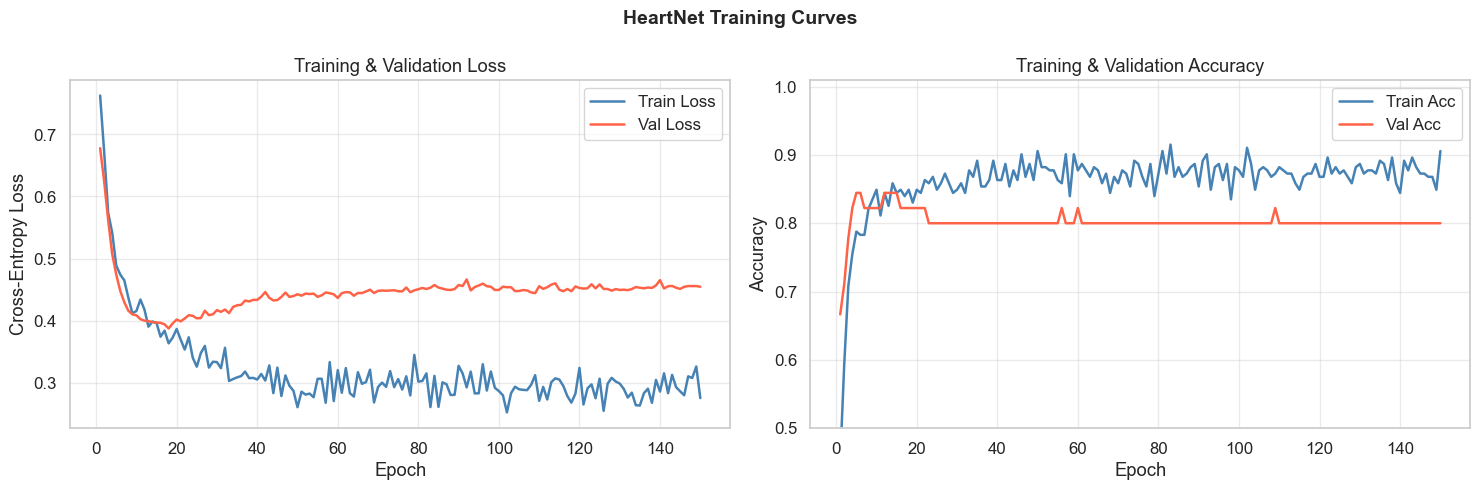

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

epochs_range = range(1, EPOCHS + 1)

# Loss curves
ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='steelblue', linewidth=1.8)
ax1.plot(epochs_range, history['val_loss'],   label='Val Loss',   color='tomato',    linewidth=1.8)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.4)

# Accuracy curves
ax2.plot(epochs_range, history['train_acc'], label='Train Acc', color='steelblue', linewidth=1.8)
ax2.plot(epochs_range, history['val_acc'],   label='Val Acc',   color='tomato',    linewidth=1.8)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training & Validation Accuracy')
ax2.set_ylim([0.5, 1.01])
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.suptitle('HeartNet Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 9 — Evaluation Metrics (on Test Set)

### Why multiple metrics?

Accuracy alone can be misleading with imbalanced data.  
For medical diagnosis, **recall (sensitivity)** is often most important — we want to minimise false negatives (missing actual disease).

| Metric | Formula | What it measures |
|--------|---------|------------------|
| Accuracy | $(TP+TN)/(P+N)$ | Overall correctness |
| Precision | $TP/(TP+FP)$ | Of predicted disease, how many actually have it |
| Recall | $TP/(TP+FN)$ | Of actual disease cases, how many we caught |
| F1 Score | $2 \cdot \frac{P \cdot R}{P+R}$ | Harmonic mean of precision & recall |
| ROC-AUC | Area under ROC curve | Discrimination ability across all thresholds |

**Confusion Matrix**:  
```
               Predicted 0   Predicted 1
Actual 0  →      TN             FP
Actual 1  →      FN             TP
```

In [26]:
# Load best model weights
model.load_state_dict(best_model_state)

# Evaluate on test set
test_loss, test_acc, test_probs, test_labels = evaluate(model, test_loader, criterion, DEVICE)
test_preds = (test_probs >= 0.5).astype(int)

# Metrics
acc    = accuracy_score(test_labels, test_preds)
f1     = f1_score(test_labels, test_preds)
auc    = roc_auc_score(test_labels, test_probs)
cm     = confusion_matrix(test_labels, test_preds)

print('=' * 45)
print(f'  TEST SET EVALUATION')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print(f'  ROC-AUC   : {auc:.4f}')
print(f'  Test Loss : {test_loss:.4f}')
print('=' * 45)
print('\nClassification Report:')
print(classification_report(test_labels, test_preds,
                             target_names=['No Disease', 'Disease']))

  TEST SET EVALUATION
  Accuracy  : 0.8478
  F1 Score  : 0.8444
  ROC-AUC   : 0.9333
  Test Loss : 0.3352

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.91      0.80      0.85        25
     Disease       0.79      0.90      0.84        21

    accuracy                           0.85        46
   macro avg       0.85      0.85      0.85        46
weighted avg       0.86      0.85      0.85        46



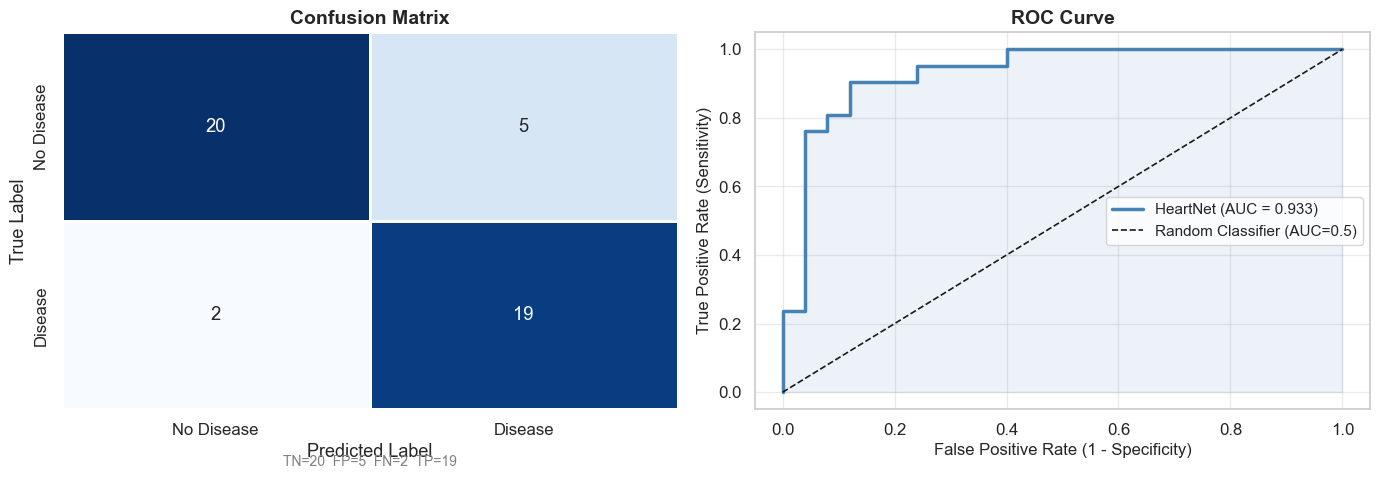

In [27]:
# ── Confusion Matrix & ROC Curve ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'],
            linewidths=1, linecolor='white', cbar=False)
ax1.set_xlabel('Predicted Label',  fontsize=13)
ax1.set_ylabel('True Label',       fontsize=13)
ax1.set_title('Confusion Matrix',  fontsize=14, fontweight='bold')

# Annotations
tn, fp, fn, tp = cm.ravel()
ax1.text(0.5, -0.15, f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
         transform=ax1.transAxes, ha='center', fontsize=10, color='gray')

# ROC Curve
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
ax2.plot(fpr, tpr, color='steelblue', linewidth=2.5,
         label=f'HeartNet (AUC = {auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random Classifier (AUC=0.5)')
ax2.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax2.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax2.set_ylabel('True Positive Rate (Sensitivity)',      fontsize=12)
ax2.set_title('ROC Curve',  fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

---
## Step 10 — Regularisation Deep Dive

Regularisation prevents **overfitting** (model performing well on training but poorly on new data).

### L2 Regularisation (Weight Decay)
Adds a penalty proportional to the squared magnitude of weights to the loss:  
$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{CE}} + \lambda \sum_i w_i^2$$  
Effect: pushes weights toward zero, preventing any single weight from dominating.

### Dropout
During each forward pass in training, randomly zero out neurons with probability `p`.  
Effect: forces the network to learn **redundant representations** — no single neuron can be relied upon.

### Experiment: Impact of Dropout Rate

We train the same architecture with different dropout values and compare validation accuracy.

In [28]:
def quick_train(dropout_p, epochs=100, lr=1e-3, wd=1e-4, hidden=[64,32]):
    """Train a HeartNet variant and return training history."""
    m = HeartNet(input_dim=13, hidden_dims=hidden, dropout_p=dropout_p).to(DEVICE)
    opt = optim.Adam(m.parameters(), lr=lr, weight_decay=wd)
    crit = nn.CrossEntropyLoss()
    
    h_train, h_val = [], []
    for _ in range(epochs):
        tl, ta = train_one_epoch(m, train_loader, crit, opt, DEVICE)
        vl, va, _, _ = evaluate(m, val_loader, crit, DEVICE)
        h_train.append(ta)
        h_val.append(va)
    return h_train, h_val


# Run experiments
dropout_vals = [0.0, 0.2, 0.4, 0.6]
results = {}
print('Running dropout experiments...')
for dp in dropout_vals:
    h_train, h_val = quick_train(dropout_p=dp, epochs=100)
    results[dp] = (h_train, h_val)
    print(f'  Dropout={dp:.1f}  |  Final Val Acc: {h_val[-1]:.3f}')
print('Done!')

Running dropout experiments...
  Dropout=0.0  |  Final Val Acc: 0.711
  Dropout=0.2  |  Final Val Acc: 0.689
  Dropout=0.4  |  Final Val Acc: 0.778
  Dropout=0.6  |  Final Val Acc: 0.800
Done!


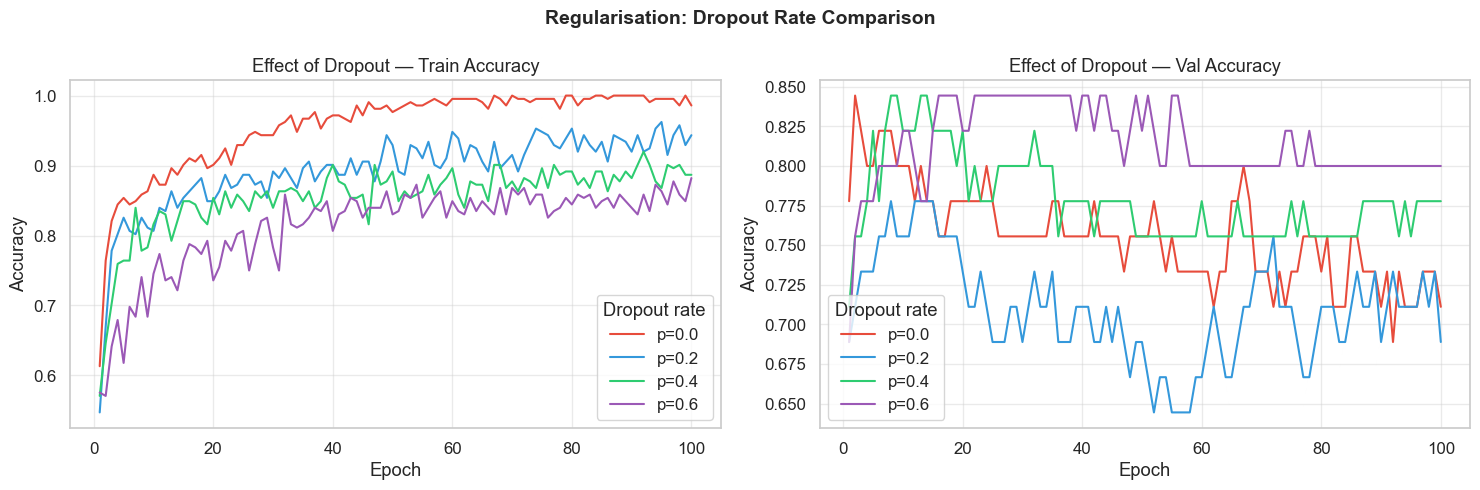

In [29]:
# Plot dropout comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

for (dp, (h_tr, h_va)), color in zip(results.items(), colors):
    ep = range(1, len(h_tr) + 1)
    axes[0].plot(ep, h_tr, color=color, linewidth=1.5, label=f'p={dp}')
    axes[1].plot(ep, h_va, color=color, linewidth=1.5, label=f'p={dp}')

for ax, title in zip(axes, ['Train Accuracy', 'Val Accuracy']):
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Effect of Dropout — {title}')
    ax.legend(title='Dropout rate')
    ax.grid(True, alpha=0.4)

plt.suptitle('Regularisation: Dropout Rate Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 11 — Learning Rate Scheduling

The **learning rate (LR)** is the most important hyperparameter in deep learning.

| LR too large | LR too small |
|--------------|--------------|
| Overshoots minima | Very slow convergence |
| Loss oscillates / diverges | Gets stuck in local minima |

### Common Schedulers

| Scheduler | Strategy |
|-----------|----------|
| **StepLR** | Multiply LR by γ every N epochs |
| **ReduceLROnPlateau** | Reduce LR when a metric stops improving |
| **CosineAnnealingLR** | Smoothly vary LR following a cosine curve |
| **OneCycleLR** | Ramp up then decay (fast training, popular with ResNets) |

### Compare: Constant LR vs StepLR vs ReduceLROnPlateau

In [30]:
def train_with_scheduler(sched_name='none', epochs=120):
    """Train model with a specific LR scheduler strategy."""
    torch.manual_seed(SEED)
    m    = HeartNet(input_dim=13, hidden_dims=[64, 32], dropout_p=0.3).to(DEVICE)
    opt  = optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()
    
    if sched_name == 'step':
        sched = StepLR(opt, step_size=30, gamma=0.5)          # halve LR every 30 epochs
    elif sched_name == 'plateau':
        sched = ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=10)
    else:
        sched = None
    
    val_acc_hist, lr_hist = [], []
    for epoch in range(1, epochs + 1):
        train_one_epoch(m, train_loader, crit, opt, DEVICE)
        vl, va, _, _ = evaluate(m, val_loader, crit, DEVICE)
        val_acc_hist.append(va)
        lr_hist.append(opt.param_groups[0]['lr'])
        
        if sched is not None:
            if sched_name == 'plateau':
                sched.step(vl)
            else:
                sched.step()
    
    return val_acc_hist, lr_hist

print('Running scheduler comparison...')
sched_results = {}
for name in ['none', 'step', 'plateau']:
    sched_results[name] = train_with_scheduler(sched_name=name, epochs=120)
    print(f'  {name:>8} | Final Val Acc: {sched_results[name][0][-1]:.3f}')
print('Done!')


Running scheduler comparison...
      none | Final Val Acc: 0.711
      step | Final Val Acc: 0.756
   plateau | Final Val Acc: 0.756
Done!


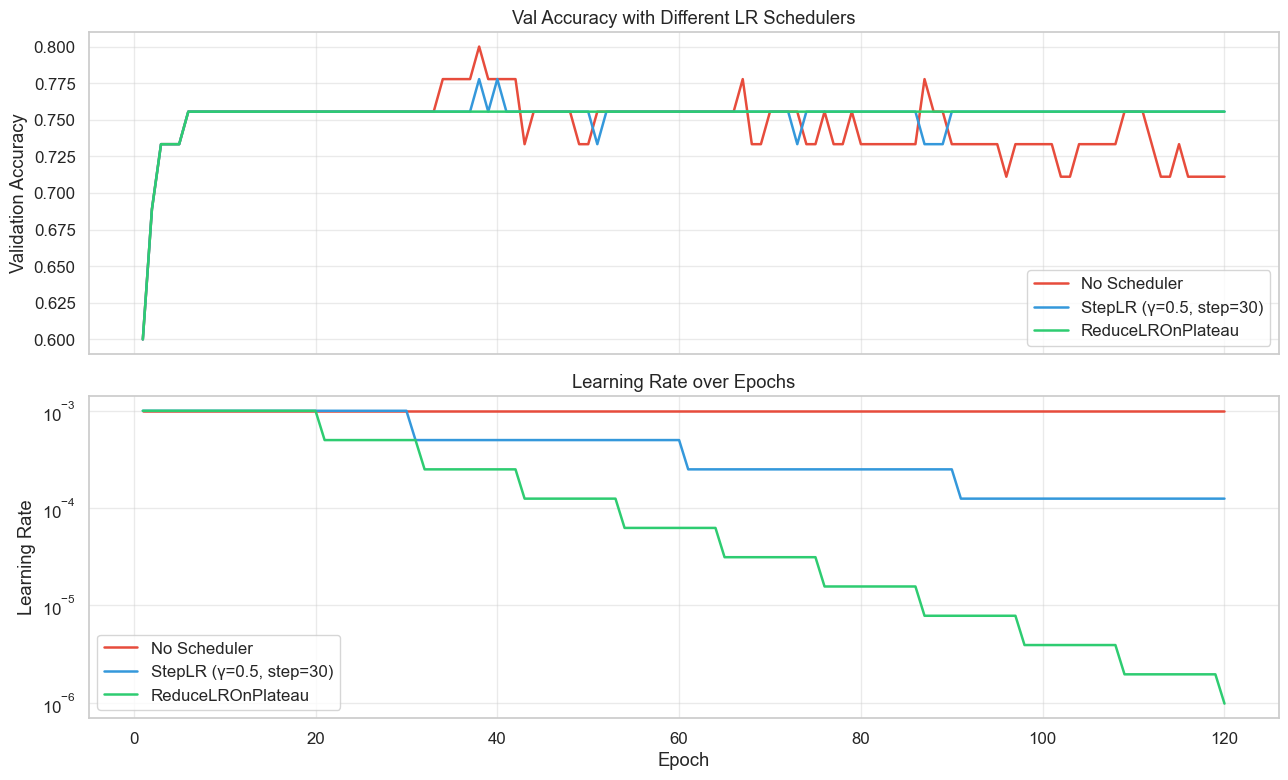

In [31]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
colors_map = {'none': '#e74c3c', 'step': '#3498db', 'plateau': '#2ecc71'}
labels_map = {'none': 'No Scheduler', 'step': 'StepLR (γ=0.5, step=30)',
              'plateau': 'ReduceLROnPlateau'}

for name, (val_acc, lr_hist) in sched_results.items():
    ep = range(1, len(val_acc) + 1)
    ax1.plot(ep, val_acc, color=colors_map[name], linewidth=1.8, label=labels_map[name])
    ax2.plot(ep, lr_hist, color=colors_map[name], linewidth=1.8, label=labels_map[name])

ax1.set_ylabel('Validation Accuracy')
ax1.set_title('Val Accuracy with Different LR Schedulers')
ax1.legend()
ax1.grid(True, alpha=0.4)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Learning Rate')
ax2.set_title('Learning Rate over Epochs')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

---
## Step 12 — Architecture Comparison: Shallow vs Deep

### Does depth always help?

More layers = more representational power, BUT:  
- More parameters → more data needed  
- Deeper networks can overfit on small datasets (like this one!)  
- Very deep networks suffer from **vanishing gradients** (solved by BatchNorm + ReLU)

We compare four architectures:

| Model | Hidden Layers | Parameters |
|-------|--------------|------------|
| Linear-only | No hidden layers | ~26 |
| Shallow | [32] | ~480 |
| Medium | [64, 32] | ~2,178 |
| Deep | [128, 64, 32] | ~10k |

In [32]:
class LinearModel(nn.Module):
    """Logistic regression baseline (no hidden layers)."""
    def __init__(self, input_dim=13):
        super().__init__()
        self.fc = nn.Linear(input_dim, 2)
    def forward(self, x):
        return self.fc(x)


architectures = {
    'Logistic Regression': lambda: LinearModel(),
    'Shallow  [32]':       lambda: HeartNet(hidden_dims=[32],        dropout_p=0.2),
    'Medium   [64,32]':    lambda: HeartNet(hidden_dims=[64, 32],    dropout_p=0.3),
    'Deep  [128,64,32]':   lambda: HeartNet(hidden_dims=[128,64,32], dropout_p=0.3),
}

arch_results = {}
print(f'{"Architecture":<25} | {"Params":>8} | {"Val Acc":>8} | {"Val AUC":>8}')
print('-' * 60)

for name, model_fn in architectures.items():
    torch.manual_seed(SEED)
    m    = model_fn().to(DEVICE)
    opt  = optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()
    
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    
    h_train_acc, h_val_acc = [], []
    for _ in range(150):
        train_one_epoch(m, train_loader, crit, opt, DEVICE)
        _, va, vp, vl = evaluate(m, val_loader, crit, DEVICE)
        h_train_acc.append(va)
        h_val_acc.append(va)
    
    _, final_acc, final_probs, final_labels = evaluate(m, val_loader, crit, DEVICE)
    final_auc = roc_auc_score(final_labels, final_probs)
    
    arch_results[name] = {'acc_hist': h_val_acc, 'acc': final_acc, 'auc': final_auc, 'params': n_params}
    print(f'{name:<25} | {n_params:>8,} | {final_acc:>8.3f} | {final_auc:>8.3f}')

Architecture              |   Params |  Val Acc |  Val AUC
------------------------------------------------------------
Logistic Regression       |       28 |    0.800 |    0.897
Shallow  [32]             |      578 |    0.756 |    0.839
Medium   [64,32]          |    3,234 |    0.733 |    0.815
Deep  [128,64,32]         |   12,642 |    0.733 |    0.810


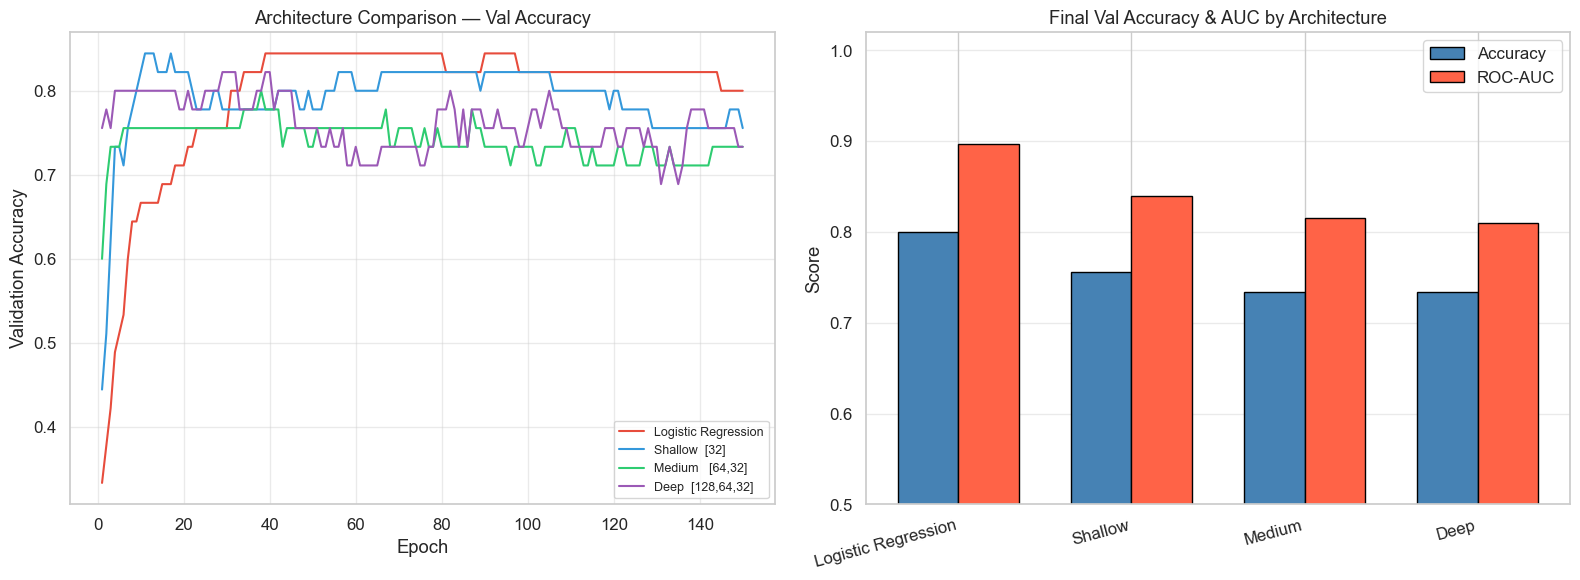

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
palette = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

for (name, res), color in zip(arch_results.items(), palette):
    ax1.plot(range(1, len(res['acc_hist'])+1), res['acc_hist'],
             color=color, linewidth=1.5, label=name)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Validation Accuracy')
ax1.set_title('Architecture Comparison — Val Accuracy')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.4)

names  = list(arch_results.keys())
accs   = [arch_results[n]['acc'] for n in names]
aucs   = [arch_results[n]['auc'] for n in names]

x = np.arange(len(names))
w = 0.35
ax2.bar(x - w/2, accs, w, label='Accuracy', color='steelblue', edgecolor='black')
ax2.bar(x + w/2, aucs, w, label='ROC-AUC',  color='tomato',    edgecolor='black')
ax2.set_xticks(x)
ax2.set_xticklabels([n.split('[')[0].strip() for n in names], rotation=15, ha='right')
ax2.set_ylim([0.5, 1.02])
ax2.set_ylabel('Score')
ax2.set_title('Final Val Accuracy & AUC by Architecture')
ax2.legend()
ax2.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

---
## Step 13 — Feature Importance & Model Explainability

Neural networks are often called **"black boxes"** — but we can explain their predictions!

### Technique 1: Permutation Feature Importance

**Idea**: Randomly scramble one feature at a time and measure how much the model's accuracy drops.  
If accuracy drops a lot → that feature is important.  
If accuracy barely changes → that feature isn't used much by the model.

**Advantage**: Model-agnostic — works with any model.

### Technique 2: SHAP (SHapley Additive exPlanations)

Based on cooperative game theory. The **Shapley value** of feature $i$ is:  
$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} [f(S \cup \{i\}) - f(S)]$$

It answers: *"How much did feature $i$ contribute to this prediction, averaged over all possible subsets of features?"*

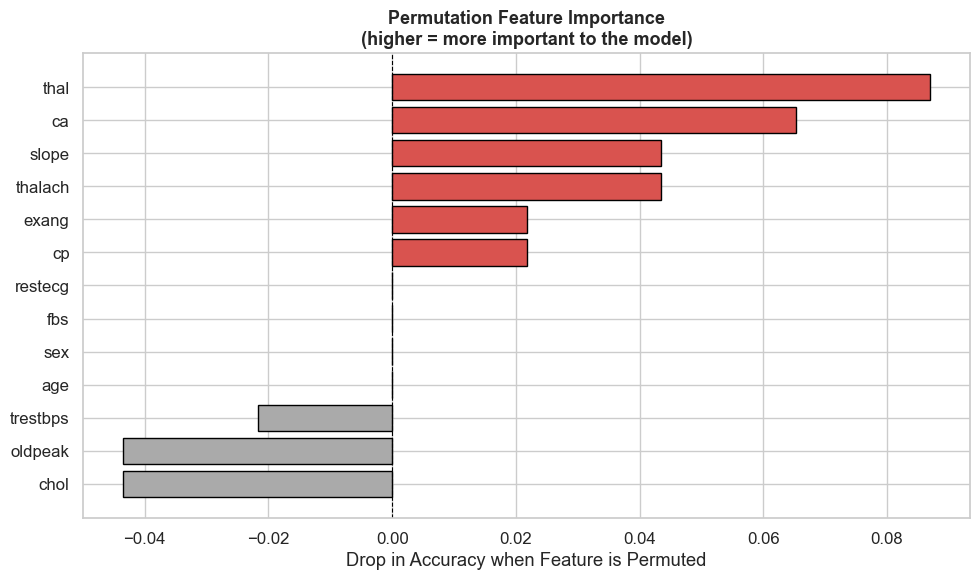

Baseline Test Accuracy: 0.848


In [35]:
# ── Permutation Feature Importance ───────────────────────────────
# Reload best HeartNet model
best_model = HeartNet(input_dim=13, hidden_dims=[64, 32], dropout_p=0.3).to(DEVICE)
best_model.load_state_dict(best_model_state)
best_model.eval()

feature_names = list(X_raw.columns)

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)

@torch.no_grad()
def get_accuracy(model, X_t, y_true):
    logits = model(X_t)
    preds = logits.argmax(dim=1).cpu().numpy()
    return accuracy_score(y_true, preds)

baseline_acc = get_accuracy(best_model, X_test_t, y_test)

importances = []
for i, feat in enumerate(feature_names):
    X_permuted = X_test_t.clone()
    perm_idx = torch.randperm(X_permuted.shape[0])
    X_permuted[:, i] = X_permuted[perm_idx, i]   # shuffle feature i
    perm_acc = get_accuracy(best_model, X_permuted, y_test)
    importances.append(baseline_acc - perm_acc)    # drop in accuracy

# Sort
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
colors_bar = ['#d9534f' if v > 0 else '#aaa' for v in imp_df['Importance']]
plt.barh(imp_df['Feature'], imp_df['Importance'], color=colors_bar, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Drop in Accuracy when Feature is Permuted')
plt.title('Permutation Feature Importance\n(higher = more important to the model)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Baseline Test Accuracy: {baseline_acc:.3f}')

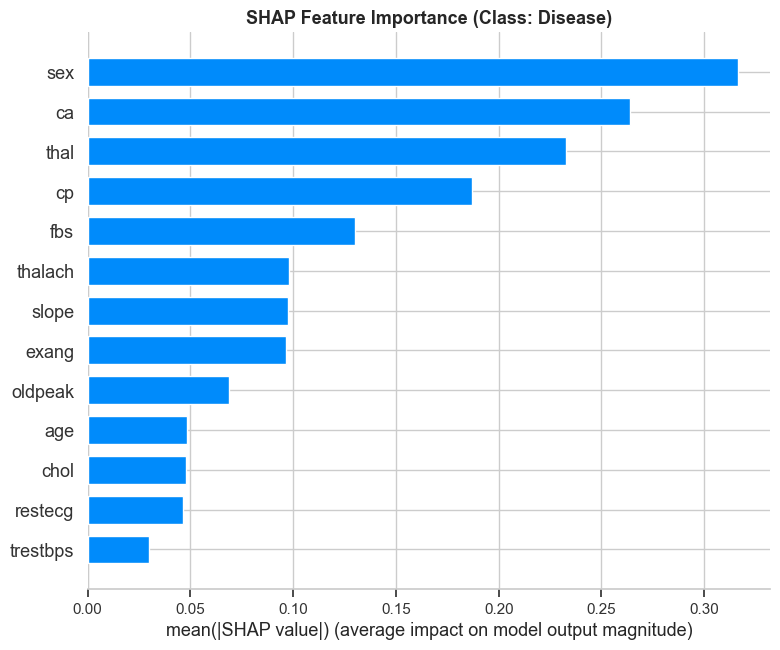

In [36]:
# ── SHAP Values ───────────────────────────────────────────────────
import shap

# SHAP DeepExplainer works natively with PyTorch models
best_model.eval()

# Use a small background sample for SHAP (summary of training distribution)
background = torch.tensor(X_train[:50], dtype=torch.float32).to(DEVICE)
test_sample = torch.tensor(X_test[:50], dtype=torch.float32).to(DEVICE)

explainer   = shap.DeepExplainer(best_model, background)
shap_values = explainer.shap_values(test_sample)  # shape: [n_samples, n_features, n_classes]

# shap_values[1] → SHAP values for class 1 (disease)
shap_disease = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_disease, test_sample.cpu().numpy(),
                  feature_names=feature_names, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Class: Disease)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

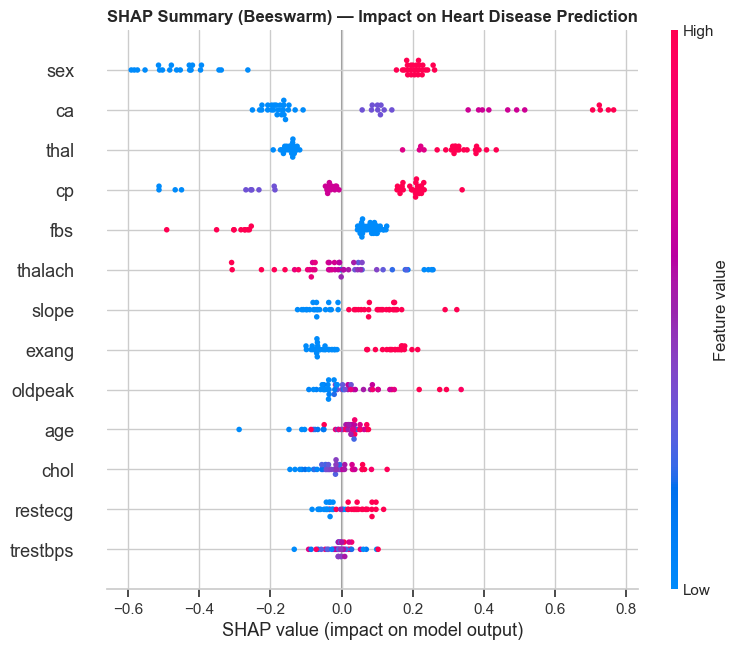

In [37]:
# ── SHAP Beeswarm / Dot Plot ──────────────────────────────────────
# Shows both direction (positive/negative) and magnitude of each feature's effect
plt.figure(figsize=(11, 7))
shap.summary_plot(shap_disease, test_sample.cpu().numpy(),
                  feature_names=feature_names, show=False)
plt.title('SHAP Summary (Beeswarm) — Impact on Heart Disease Prediction',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 14 — Summary & Key Takeaways

### What We Built & Learned

| Topic | Key Insight |
|-------|-------------|
| **Data Loading & EDA** | Always understand your data before modelling. Check distributions, missing values, and class balance. |
| **Preprocessing** | Scale features (StandardScaler). Fit scaler on train only to prevent data leakage. |
| **PyTorch Dataset/DataLoader** | Provides efficient mini-batch iteration with shuffling. Essential for training loops. |
| **Neural Network Architecture** | Linear layers transform features; ReLU adds non-linearity; depth increases capacity. |
| **Loss & Optimizer** | CrossEntropyLoss for classification; Adam adapts the learning rate per parameter. |
| **Training Loop** | Forward → Loss → Zero grad → Backward → Step. Always switch between `train()` / `eval()` modes. |
| **Batch Normalization** | Stabilises training by normalising layer inputs. Acts as implicit regularisation. |
| **Dropout** | Randomly disables neurons. Prevents co-adaptation. Use higher `p` for larger models. |
| **Learning Rate Scheduling** | Reduces LR over time to fine-tune. `ReduceLROnPlateau` is robust and adaptive. |
| **Evaluation Metrics** | Accuracy alone is insufficient. Use F1, ROC-AUC, and confusion matrix for a complete picture. |
| **Architecture Depth** | More layers ≠ always better — especially on small datasets like this one. |
| **Explainability** | Permutation importance and SHAP reveal which features the model relies on. |

### Clinical Insights

Based on SHAP & permutation importance, the most predictive features are typically:
1. **`ca`** — number of major vessels coloured by fluoroscopy  
2. **`thal`** — thalassemia type (fixed vs reversible defect)  
3. **`cp`** — chest pain type  
4. **`oldpeak`** — ST depression  
5. **`thalach`** — max heart rate achieved  

These align with known cardiological risk indicators. Deep learning can validate and surface these clinical signals from raw patient data.

---

### Next Steps to Explore

- [ ] **Cross-validation** (k-fold) for more robust evaluation on this small dataset  
- [ ] **Class-weighted loss** to handle class imbalance more explicitly  
- [ ] **Threshold tuning** — adjust the 0.5 decision threshold based on clinical needs (prefer recall over precision)  
- [ ] **Ensemble methods** — combine multiple FNN models  
- [ ] **Hyperparameter search** using `Optuna` or `Ray Tune`  
- [ ] **Attention mechanisms** or **residual connections** for deeper architectures